===== MODEL EVALUATION =====

===== ACTUAL VS PREDICTED =====
              Actual          Predicted
0  Needs Improvement  Needs Improvement
1     High Performer     High Performer
2     High Performer     High Performer

===== MODEL EVALUATION METRICS =====
Accuracy: 100.0 %
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

===== CONFUSION MATRIX =====
[[2 0]
 [0 1]]


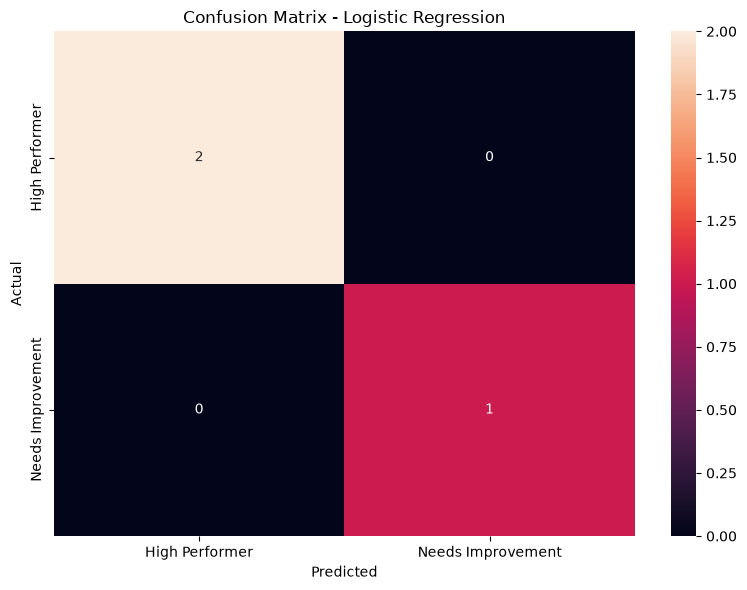


===== CLASSIFICATION REPORT =====
                   precision    recall  f1-score   support

   High Performer       1.00      1.00      1.00         2
Needs Improvement       1.00      1.00      1.00         1

         accuracy                           1.00         3
        macro avg       1.00      1.00      1.00         3
     weighted avg       1.00      1.00      1.00         3


===== PERFORMANCE SUMMARY =====
Accuracy: 100.0 %
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

===== METRIC INTERPRETATION =====
Accuracy measures the overall percentage of correct predictions.
Precision measures how many students predicted as High Performers were actually High Performers.
Recall measures how many actual High Performers were correctly identified.
F1 Score provides a balance between Precision and Recall.

===== DATASET-SPECIFIC OBSERVATION =====
For this student performance dataset, Recall is useful because it measures how effectively the model identifies actual High Performers.
F1 Score

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("cleaned_students.csv")

print("===== MODEL EVALUATION =====")

df["Average_Marks"] = (df["Python"] + df["Math"] + df["Science"]) / 3

df["Performance"] = df["Average_Marks"].apply(
    lambda x: "High Performer" if x >= 80 else "Needs Improvement"
)

X = df[["Attendance"]]
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="High Performer", zero_division=0)
recall = recall_score(y_test, y_pred, pos_label="High Performer", zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label="High Performer", zero_division=0)

print("\n===== ACTUAL VS PREDICTED =====")
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
print(results)

print("\n===== MODEL EVALUATION METRICS =====")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["High Performer", "Needs Improvement"]
)

print("\n===== CONFUSION MATRIX =====")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["High Performer", "Needs Improvement"],
    yticklabels=["High Performer", "Needs Improvement"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, zero_division=0))

print("\n===== PERFORMANCE SUMMARY =====")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

print("\n===== METRIC INTERPRETATION =====")
print("Accuracy measures the overall percentage of correct predictions.")
print("Precision measures how many students predicted as High Performers were actually High Performers.")
print("Recall measures how many actual High Performers were correctly identified.")
print("F1 Score provides a balance between Precision and Recall.")

print("\n===== DATASET-SPECIFIC OBSERVATION =====")
print("For this student performance dataset, Recall is useful because it measures how effectively the model identifies actual High Performers.")
print("F1 Score is also useful because it balances Precision and Recall.")

print("\n===== MODEL EVALUATION COMPLETED =====")

# 📊 Model Evaluation

## Project Overview

This project evaluates the Logistic Regression classification model created in the previous task.

The model classifies students into two categories:

- High Performer
- Needs Improvement

The model is evaluated using Accuracy, Precision, Recall, F1 Score, and a Confusion Matrix.

## Evaluation Metrics

### Accuracy

Measures the percentage of total predictions that are correct.

### Precision

Measures how many students predicted as High Performers were actually High Performers.

### Recall

Measures how many actual High Performers were correctly identified by the model.

### F1 Score

Provides a balance between Precision and Recall.

## Confusion Matrix

A confusion matrix is used to compare the actual and predicted classifications and identify correct and incorrect predictions.

## Dataset-Specific Metric

For this student performance dataset, Recall is particularly useful when the objective is to identify as many actual High Performers as possible.

F1 Score is also useful because it balances Precision and Recall.

## Technologies Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## 📚 Reference

Scikit-learn Metrics Documentation:

https://scikit-learn.org/stable/modules/model_evaluation.html